# RAG Eval — Шаг 2: Метрики Retrieval (top_k = 3, 5, 7)

Для каждого вопроса из `rag_qa_dataset.xlsx`:
- Запускаем `GraphRetriever` для пользователя `linker_eval_gpt-5.2`
- Получаем top-k zettel_id-ов (entry_points)
- Сравниваем с `ground_truth_zettel_ids`
- Считаем: **Precision@k, Recall@k, F1@k, MRR, nDCG@k, HitRate@k**

Результаты сохраняются в `metric_results/rag/retrieval/`.

In [4]:
import os
import sys
import json
import time
import logging
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from tqdm import tqdm
from dotenv import load_dotenv

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))
load_dotenv(PROJECT_ROOT / '.env')

from zettelkasten.graph_rag import GraphRetriever
from zettelkasten.linker import LocalEmbeddingModel
from storage.neo4j.client import get_neo4j_client
from storage.neo4j.repository import ZettelRepository

logging.basicConfig(level=logging.WARNING)
print('✅ imports ok')

✅ imports ok


In [5]:
EVAL_USER_ID = 'linker_eval_gpt-5.2'
TOP_K_VALUES = [3, 5, 7]
SIMILARITY_THRESHOLD = 0.20   # мягкий порог чтобы получать кандидатов для всех top_k

QA_DATASET_PATH = Path('synthetic_datasets/rag_qa_dataset.xlsx')
OUTPUT_DIR      = Path('metric_results/rag/retrieval')
FIGURES_DIR     = OUTPUT_DIR / 'figures'

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
print(f'Output dir: {OUTPUT_DIR}')

Output dir: metric_results/rag/retrieval


In [6]:
df_qa = pd.read_excel(QA_DATASET_PATH)

# Используем только вопросы с непустым ground truth
df_eval = df_qa[df_qa['n_gt_zettels'] > 0].reset_index(drop=True)

print(f'Total Q&A pairs: {len(df_qa)}')
print(f'Eval subset (with GT zettels): {len(df_eval)}')
print(f'Dropped (no GT): {len(df_qa) - len(df_eval)}')
df_eval[['question_id', 'question', 'n_gt_zettels', 'question_type']].head(5)

Total Q&A pairs: 199
Eval subset (with GT zettels): 131
Dropped (no GT): 68


,question_id,question,n_gt_zettels,question_type
0,Q-0A1D247E,"Напомни, какой именно лимит на экспресс-достав...",1,factual
1,Q-FB4EB54F,"Напомни, какую оценку по потере MRR называла К...",5,factual
2,Q-C1D4BCA0,"Напомни, до какой даты мы договорились замороз...",1,factual
3,Q-9D4A1AFE,"Напомни, какие именно ограничения по LTV и CAC...",1,factual
4,Q-4C10A243,"Напомни, какое конкретное решение мы тогда при...",1,decision


In [7]:
embedding_model = LocalEmbeddingModel()
neo4j_client    = get_neo4j_client()
repository      = ZettelRepository(neo4j_client)

retriever = GraphRetriever(
    embedding_model=embedding_model,
    repository=repository,
    search_limit=max(TOP_K_VALUES) + 3,   # берём с запасом
    context_hops=0,                        # только entry points для чистоты метрик retrieval
)

# Проверяем подключение
test_q = df_eval['question'].iloc[0]
ctx = retriever.retrieve(EVAL_USER_ID, test_q, similarity_threshold=SIMILARITY_THRESHOLD)
print(f'✅ Retriever OK. Test query entry points: {len(ctx.entry_points)}')

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 8465.26it/s]
/Users/nastya/github/Executive_Exocortex/zettelkasten/linker.py:84: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  return self.model.get_sentence_embedding_dimension()


[EmbeddingModel] intfloat/multilingual-e5-base загружена за 7.6с (dim=768, device=mps)
obunar63
[Neo4j] Подключено к bolt://localhost:7687


✅ Retriever OK. Test query entry points: 10


In [8]:
def precision_at_k(retrieved: list[str], relevant: set[str], k: int) -> float:
    top_k = retrieved[:k]
    hits  = sum(1 for r in top_k if r in relevant)
    return hits / k if k > 0 else 0.0


def recall_at_k(retrieved: list[str], relevant: set[str], k: int) -> float:
    if not relevant:
        return 0.0
    top_k = retrieved[:k]
    hits  = sum(1 for r in top_k if r in relevant)
    return hits / len(relevant)


def f1_at_k(p: float, r: float) -> float:
    return 2 * p * r / (p + r) if (p + r) > 0 else 0.0


def hit_rate_at_k(retrieved: list[str], relevant: set[str], k: int) -> float:
    return 1.0 if any(r in relevant for r in retrieved[:k]) else 0.0


def reciprocal_rank(retrieved: list[str], relevant: set[str]) -> float:
    for i, r in enumerate(retrieved):
        if r in relevant:
            return 1.0 / (i + 1)
    return 0.0


def ndcg_at_k(retrieved: list[str], relevant: set[str], k: int) -> float:
    top_k = retrieved[:k]
    dcg  = sum(
        1.0 / np.log2(i + 2)
        for i, r in enumerate(top_k)
        if r in relevant
    )
    ideal_hits = min(k, len(relevant))
    idcg = sum(1.0 / np.log2(i + 2) for i in range(ideal_hits))
    return dcg / idcg if idcg > 0 else 0.0


print('✅ Metric functions defined')

✅ Metric functions defined


In [9]:
raw_records = []

for _, row in tqdm(df_eval.iterrows(), total=len(df_eval), desc='Running retrieval eval'):
    question_id = row['question_id']
    question    = row['question']
    gt_ids      = set(json.loads(row['ground_truth_zettel_ids']))

    t0 = time.time()
    try:
        ctx = retriever.retrieve(
            EVAL_USER_ID, question,
            similarity_threshold=SIMILARITY_THRESHOLD,
        )
        retrieved_ids = [node.zettel_id for node in ctx.entry_points]
        latency_ms    = int((time.time() - t0) * 1000)
    except Exception as e:
        logging.warning(f'Retrieval error for {question_id}: {e}')
        retrieved_ids = []
        latency_ms    = -1

    rr = reciprocal_rank(retrieved_ids, gt_ids)

    for k in TOP_K_VALUES:
        p  = precision_at_k(retrieved_ids, gt_ids, k)
        r  = recall_at_k(retrieved_ids, gt_ids, k)
        f1 = f1_at_k(p, r)
        hr = hit_rate_at_k(retrieved_ids, gt_ids, k)
        nd = ndcg_at_k(retrieved_ids, gt_ids, k)

        raw_records.append({
            'question_id':       question_id,
            'question':          question,
            'question_type':     row.get('question_type', ''),
            'note_domain':       row.get('note_domain', ''),
            'k':                 k,
            'n_retrieved':       len(retrieved_ids),
            'n_gt_zettels':      len(gt_ids),
            'precision_at_k':    p,
            'recall_at_k':       r,
            'f1_at_k':           f1,
            'hit_rate_at_k':     hr,
            'mrr':               rr,
            'ndcg_at_k':         nd,
            'latency_ms':        latency_ms,
            'retrieved_ids':     json.dumps(retrieved_ids, ensure_ascii=False),
            'gt_ids':            row['ground_truth_zettel_ids'],
        })

df_raw = pd.DataFrame(raw_records)
print(f'Raw records: {len(df_raw)}')
df_raw.head(6)

Running retrieval eval: 100%|██████████| 131/131 [00:43<00:00,  3.04it/s]

Raw records: 393


,question_id,question,question_type,note_domain,k,n_retrieved,n_gt_zettels,precision_at_k,recall_at_k,f1_at_k,hit_rate_at_k,mrr,ndcg_at_k,latency_ms,retrieved_ids,gt_ids
0,Q-0A1D247E,"Напомни, какой именно лимит на экспресс-достав...",factual,операционная деятельность,3,10,1,0.000000,0.0,0.000000,0.0,0.000000,0.000000,435,"[""ec29692a-3b9b-46af-bc64-7b49e192bdfa"", ""3a47...","[""fa44b3b5-f93c-40ee-bdee-870f0f1a08a1""]"
1,Q-0A1D247E,"Напомни, какой именно лимит на экспресс-достав...",factual,операционная деятельность,5,10,1,0.000000,0.0,0.000000,0.0,0.000000,0.000000,435,"[""ec29692a-3b9b-46af-bc64-7b49e192bdfa"", ""3a47...","[""fa44b3b5-f93c-40ee-bdee-870f0f1a08a1""]"
2,Q-0A1D247E,"Напомни, какой именно лимит на экспресс-достав...",factual,операционная деятельность,7,10,1,0.000000,0.0,0.000000,0.0,0.000000,0.000000,435,"[""ec29692a-3b9b-46af-bc64-7b49e192bdfa"", ""3a47...","[""fa44b3b5-f93c-40ee-bdee-870f0f1a08a1""]"
3,Q-FB4EB54F,"Напомни, какую оценку по потере MRR называла К...",factual,аналитика и метрики,3,10,5,0.000000,0.0,0.000000,0.0,0.166667,0.000000,309,"[""8b9c0d07-b84a-4d67-8fed-a6501d98d4fc"", ""a524...","[""cd4790f7-8b58-4c57-bfc3-13b1d2d3a464"", ""ec29..."
4,Q-FB4EB54F,"Напомни, какую оценку по потере MRR называла К...",factual,аналитика и метрики,5,10,5,0.000000,0.0,0.000000,0.0,0.166667,0.000000,309,"[""8b9c0d07-b84a-4d67-8fed-a6501d98d4fc"", ""a524...","[""cd4790f7-8b58-4c57-bfc3-13b1d2d3a464"", ""ec29..."
5,Q-FB4EB54F,"Напомни, какую оценку по потере MRR называла К...",factual,аналитика и метрики,7,10,5,0.142857,0.2,0.166667,1.0,0.166667,0.120811,309,"[""8b9c0d07-b84a-4d67-8fed-a6501d98d4fc"", ""a524...","[""cd4790f7-8b58-4c57-bfc3-13b1d2d3a464"", ""ec29..."


In [10]:
raw_path = OUTPUT_DIR / 'retrieval_raw.xlsx'
df_raw.to_excel(raw_path, index=False)
print(f'Raw results saved: {raw_path}')

Raw results saved: metric_results/rag/retrieval/retrieval_raw.xlsx


In [11]:
METRICS = ['precision_at_k', 'recall_at_k', 'f1_at_k', 'hit_rate_at_k', 'mrr', 'ndcg_at_k']

summary = df_raw.groupby('k')[METRICS].agg(['mean', 'median', 'std']).round(4)
summary.columns = ['_'.join(c) for c in summary.columns]

summary_path = OUTPUT_DIR / 'retrieval_summary.xlsx'
summary.to_excel(summary_path)
print(f'Summary saved: {summary_path}')
print('\n=== Summary by top_k ===')
display(summary)

Summary saved: metric_results/rag/retrieval/retrieval_summary.xlsx

=== Summary by top_k ===


,precision_at_k_mean,precision_at_k_median,precision_at_k_std,recall_at_k_mean,recall_at_k_median,recall_at_k_std,f1_at_k_mean,f1_at_k_median,f1_at_k_std,hit_rate_at_k_mean,hit_rate_at_k_median,hit_rate_at_k_std,mrr_mean,mrr_median,mrr_std,ndcg_at_k_mean,ndcg_at_k_median,ndcg_at_k_std
k,,,,,,,,,,,,,,,,,,
3,0.0941,0.0,0.1951,0.0877,0.0,0.2342,0.0725,0.0,0.1546,0.2214,0.0,0.4168,0.1887,0.0,0.3437,0.1240,0.0,0.2592
5,0.0718,0.0,0.1427,0.1008,0.0,0.2409,0.0684,0.0,0.1303,0.2519,0.0,0.4358,0.1887,0.0,0.3437,0.1162,0.0,0.2353
7,0.0687,0.0,0.1318,0.1191,0.0,0.2492,0.0732,0.0,0.1277,0.2977,0.0,0.4590,0.1887,0.0,0.3437,0.1212,0.0,0.2315


In [12]:
# Выбираем best top_k по F1
f1_by_k  = df_raw.groupby('k')['f1_at_k'].mean()
best_k   = int(f1_by_k.idxmax())
best_f1  = f1_by_k.max()

print(f'\n📊 F1@k by top_k:')
for k, v in f1_by_k.items():
    marker = ' ← best' if k == best_k else ''
    print(f'  top_{k}: F1 = {v:.4f}{marker}')

print(f'\n✅ Best top_k = {best_k} (F1={best_f1:.4f})')
print(f'   → Используем top_k={best_k} для оценки генератора (Notebook 3)')

# Сохраняем best_k для Notebook 3
with open(OUTPUT_DIR / 'best_k.json', 'w') as f:
    json.dump({'best_k': best_k, 'f1': float(best_f1)}, f)
print(f'Saved best_k.json')


📊 F1@k by top_k:
  top_3: F1 = 0.0725
  top_5: F1 = 0.0684
  top_7: F1 = 0.0732 ← best

✅ Best top_k = 7 (F1=0.0732)
   → Используем top_k=7 для оценки генератора (Notebook 3)
Saved best_k.json


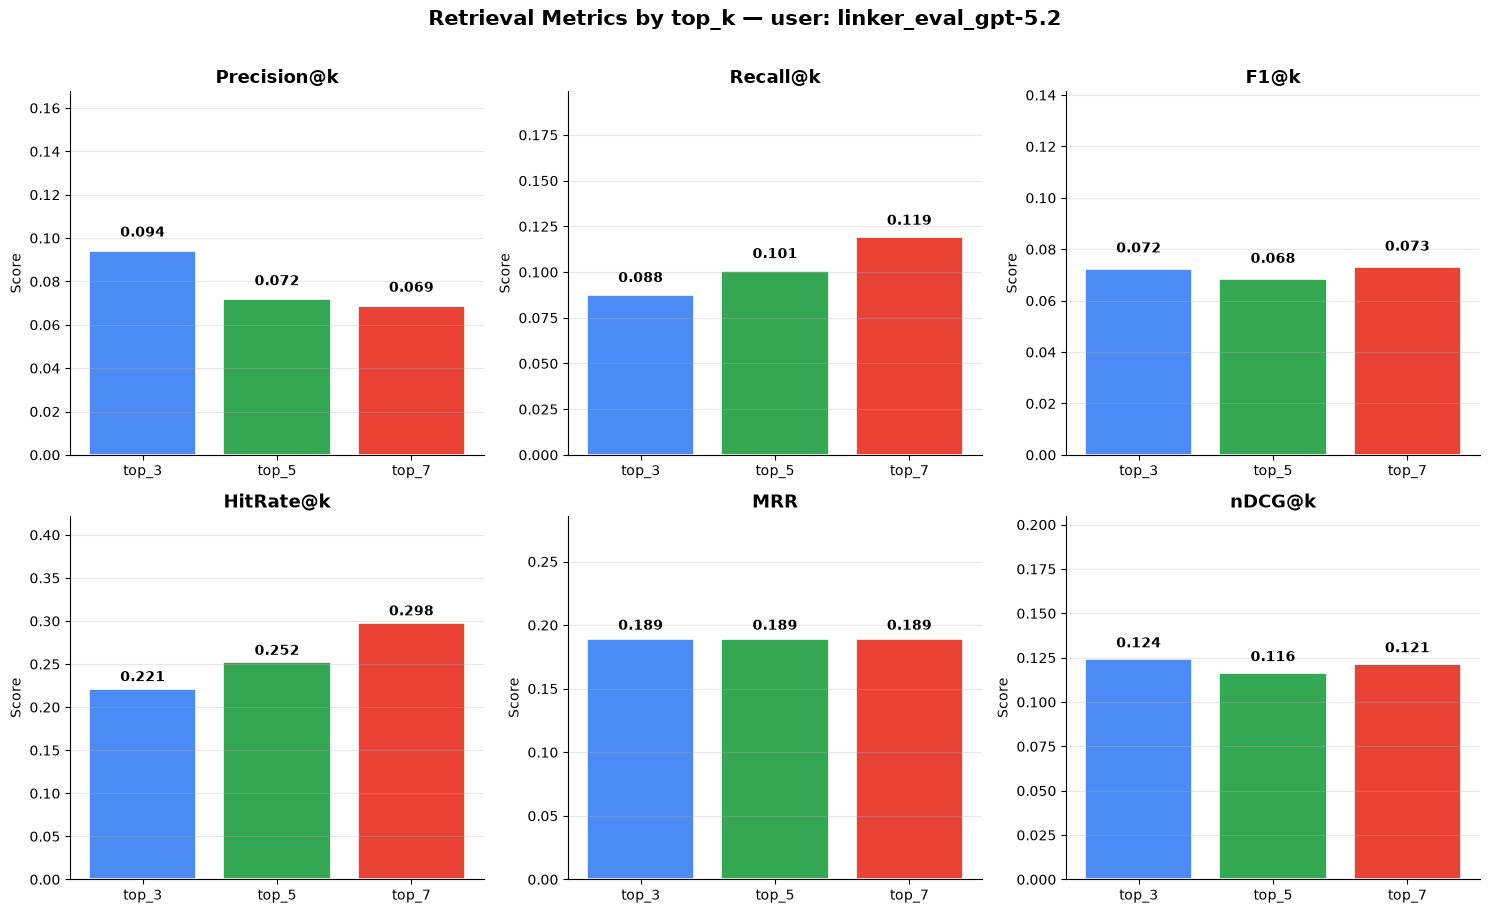

Saved retrieval_metrics_bar.png


In [13]:
means = df_raw.groupby('k')[METRICS].mean().reset_index()

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

palette = ['#4C8BF5', '#34A853', '#EA4335']
metric_names = {
    'precision_at_k': 'Precision@k',
    'recall_at_k':    'Recall@k',
    'f1_at_k':        'F1@k',
    'hit_rate_at_k':  'HitRate@k',
    'mrr':            'MRR',
    'ndcg_at_k':      'nDCG@k',
}

for ax, (metric, label) in zip(axes, metric_names.items()):
    vals = means[metric].values
    bars = ax.bar(
        [f'top_{k}' for k in TOP_K_VALUES], vals,
        color=palette, edgecolor='white', linewidth=1.2
    )
    for bar, v in zip(bars, vals):
        ax.text(
            bar.get_x() + bar.get_width() / 2, v + 0.005,
            f'{v:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold'
        )
    ax.set_title(label, fontsize=13, fontweight='bold')
    ax.set_ylim(0, min(1.15, max(vals) * 1.25 + 0.05))
    ax.set_ylabel('Score')
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(axis='y', alpha=0.3)

fig.suptitle(f'Retrieval Metrics by top_k — user: {EVAL_USER_ID}', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
fig.savefig(FIGURES_DIR / 'retrieval_metrics_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved retrieval_metrics_bar.png')

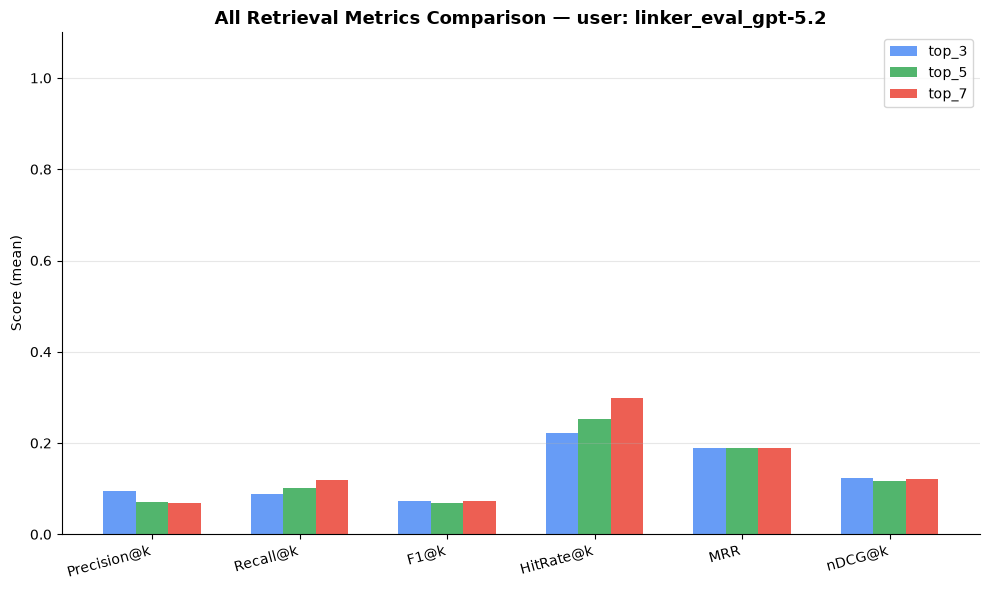

Saved retrieval_grouped_bar.png


In [14]:
from matplotlib.patches import FancyArrowPatch
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(METRICS))
width = 0.22

for i, k in enumerate(TOP_K_VALUES):
    row   = means[means['k'] == k].iloc[0]
    vals  = [row[m] for m in METRICS]
    bars  = ax.bar(x + (i - 1) * width, vals, width, label=f'top_{k}', color=palette[i], alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels([metric_names[m] for m in METRICS], rotation=15, ha='right')
ax.set_ylabel('Score (mean)')
ax.set_title(f'All Retrieval Metrics Comparison — user: {EVAL_USER_ID}', fontsize=13, fontweight='bold')
ax.set_ylim(0, 1.1)
ax.legend()
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
fig.savefig(FIGURES_DIR / 'retrieval_grouped_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved retrieval_grouped_bar.png')

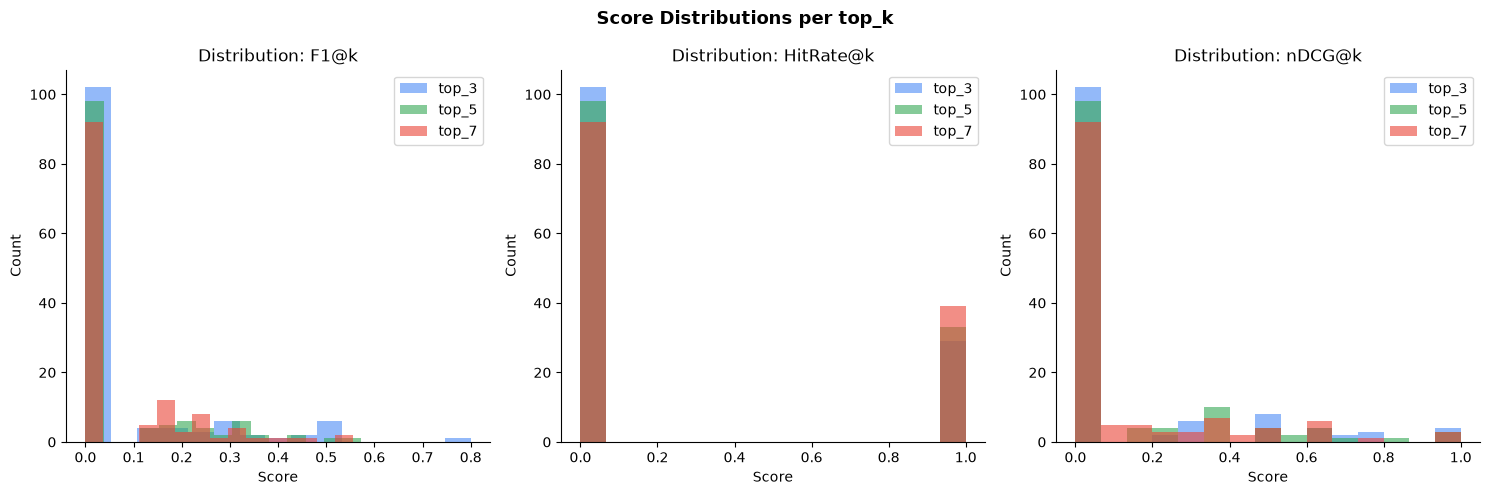

Saved retrieval_distributions.png


In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
focus_metrics = ['f1_at_k', 'hit_rate_at_k', 'ndcg_at_k']
focus_labels  = ['F1@k', 'HitRate@k', 'nDCG@k']

for ax, metric, label in zip(axes, focus_metrics, focus_labels):
    for i, k in enumerate(TOP_K_VALUES):
        vals = df_raw[df_raw['k'] == k][metric].values
        ax.hist(vals, bins=15, alpha=0.6, label=f'top_{k}', color=palette[i])
    ax.set_title(f'Distribution: {label}', fontsize=12)
    ax.set_xlabel('Score')
    ax.set_ylabel('Count')
    ax.legend()
    ax.spines[['top', 'right']].set_visible(False)

fig.suptitle('Score Distributions per top_k', fontsize=13, fontweight='bold')
plt.tight_layout()
fig.savefig(FIGURES_DIR / 'retrieval_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved retrieval_distributions.png')

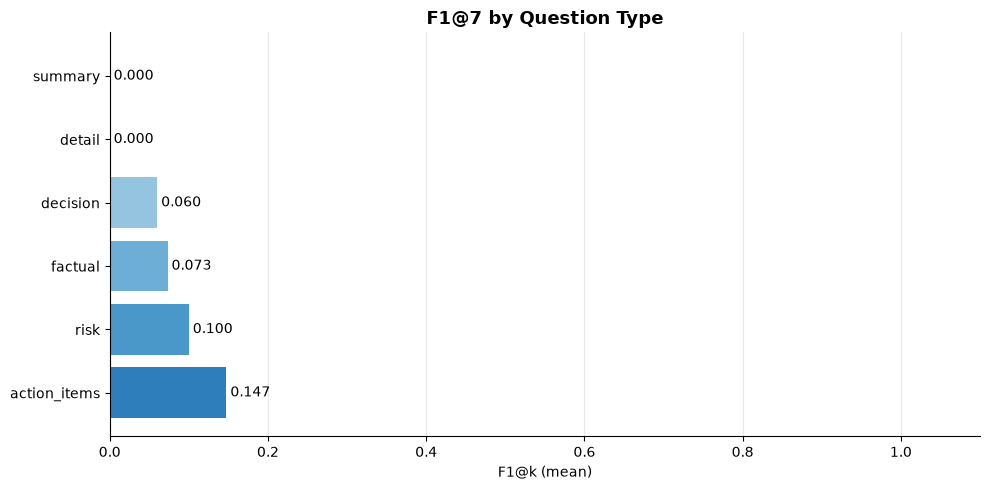

Saved f1_by_question_type.png


In [16]:
# F1 по типам вопросов для лучшего top_k
df_best_k = df_raw[df_raw['k'] == best_k]
by_type   = df_best_k.groupby('question_type')['f1_at_k'].mean().sort_values(ascending=False)

if len(by_type) > 1:
    fig, ax = plt.subplots(figsize=(10, 5))
    colors = plt.cm.Blues_r(np.linspace(0.3, 0.8, len(by_type)))
    bars = ax.barh(by_type.index, by_type.values, color=colors)
    for bar, v in zip(bars, by_type.values):
        ax.text(v + 0.005, bar.get_y() + bar.get_height()/2,
                f'{v:.3f}', va='center', fontsize=10)
    ax.set_xlabel('F1@k (mean)')
    ax.set_title(f'F1@{best_k} by Question Type', fontsize=13, fontweight='bold')
    ax.set_xlim(0, 1.1)
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    fig.savefig(FIGURES_DIR / 'f1_by_question_type.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved f1_by_question_type.png')

In [17]:
report_lines = [
    '=== RAG RETRIEVAL EVALUATION REPORT ===',
    f'User ID:          {EVAL_USER_ID}',
    f'Dataset:          {QA_DATASET_PATH}',
    f'Evaluated:        {len(df_eval)} questions',
    f'Similarity thr.:  {SIMILARITY_THRESHOLD}',
    f'Generated at:     {datetime.now().isoformat()}',
    '',
    '--- Metrics by top_k ---',
]
for k in TOP_K_VALUES:
    subset = df_raw[df_raw['k'] == k]
    report_lines.append(f'\ntop_k = {k}:')
    for m in METRICS:
        report_lines.append(f'  {metric_names[m]:<16} mean={subset[m].mean():.4f}  median={subset[m].median():.4f}  std={subset[m].std():.4f}')

report_lines += [
    '',
    f'--- Best top_k ---',
    f'best_k = {best_k}  (highest mean F1={best_f1:.4f})',
]

report_text = '\n'.join(report_lines)
print(report_text)

with open(OUTPUT_DIR / 'retrieval_report.txt', 'w', encoding='utf-8') as f:
    f.write(report_text)
print(f'\nReport saved: {OUTPUT_DIR / "retrieval_report.txt"}')

=== RAG RETRIEVAL EVALUATION REPORT ===
User ID:          linker_eval_gpt-5.2
Dataset:          synthetic_datasets/rag_qa_dataset.xlsx
Evaluated:        131 questions
Similarity thr.:  0.2
Generated at:     2026-06-28T17:15:07.433262

--- Metrics by top_k ---

top_k = 3:
  Precision@k      mean=0.0941  median=0.0000  std=0.1951
  Recall@k         mean=0.0877  median=0.0000  std=0.2342
  F1@k             mean=0.0725  median=0.0000  std=0.1546
  HitRate@k        mean=0.2214  median=0.0000  std=0.4168
  MRR              mean=0.1887  median=0.0000  std=0.3437
  nDCG@k           mean=0.1240  median=0.0000  std=0.2592

top_k = 5:
  Precision@k      mean=0.0718  median=0.0000  std=0.1427
  Recall@k         mean=0.1008  median=0.0000  std=0.2409
  F1@k             mean=0.0684  median=0.0000  std=0.1303
  HitRate@k        mean=0.2519  median=0.0000  std=0.4358
  MRR              mean=0.1887  median=0.0000  std=0.3437
  nDCG@k           mean=0.1162  median=0.0000  std=0.2353

top_k = 7:
  Precis